Colab de referência: https://colab.research.google.com/drive/13J8VuT8tDkdazsZa4w36h_tj3Z5QuVuI


## Tipos de Regressão
Existem vários tipos de modelos de regressão, cada um com suas características e aplicações específicas:
- **Regressão Linear:** Simples e múltipla, modela a relação linear entre variáveis. É o ponto de partida para muitos estudos de regressão.
- **Regressão Ridge, Lasso e Elastic Net:** Incorporam penalizações para lidar com multicolinearidade e reduzir a complexidade do modelo, prevenindo sobreajuste.
- **Árvores de Regressão:** As árvores de regressão são uma técnica de aprendizado de máquina que utiliza uma estrutura em forma de árvore para modelar a relação entre uma variável dependente contínua e uma ou mais variáveis independentes.
- **RNN (Recurrent Neural Network) ou Rede Neural Recorrente:** é um tipo de arquitetura de rede neural projetada para processar sequências de dados. Suas principais características são: a existência de loops internos que permitem que informações persistam; sua capacidade de lidar com entradas e saídas de comprimento variável; o compartilhamento de parâmetros ao longo do tempo, reduzindo o número total de parâmetros a serem aprendidos. Especialmente útil para tarefas que envolvem dados sequenciais, como processamento de linguagem natural, reconhecimento de fala e previsão de séries temporais.

### Regressão Linear

- **Definição:** A regressão linear é um método estatístico para modelar a relação entre uma variável dependente e uma ou mais variáveis independentes assumindo uma relação linear.
- **Fórmula:** $ y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_n x_n + \epsilon $
- **Interpretação:** Utilizada quando se espera que a variável dependente varie linearmente com as variáveis independentes.
### Explicação Detalhada da Regressão Linear

A regressão linear simples assume a seguinte fórmula:

$ y = \beta_0 + \beta_1 X + \epsilon $

onde:
- $ y $ é a variável dependente.
- $ X $ é a variável independente.
- $ \beta_0 $ é o intercepto (valor de $ y $ quando $ X = 0 $).
- $ \beta_1 $ é o coeficiente de inclinação (quanto $ y $ muda com uma unidade de mudança em $ X $).
- $ \epsilon $ é o termo de erro (a diferença entre os valores observados e os valores preditos).

#### Exemplo - Aplicação da Regressão Linear

Nesse exemplo é proposta a criação de um modelo linear para ser possível predizer qual seria o valor esperado de produção de uma máquina conforme fosse o ajuste de sua velocidade de produção.
- Em $X$ temos a velocidade de produção de uma máquina
- Em $y$ temos a quantidade de produtos produzidos

Passo 1: Carregamento dos dados

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Gerar dados aleatórios
np.random.seed(42)
X = 2 * np.random.rand(10, 1)
# Ordena os dados de X
X = sorted(X)
# Adequa o formato
X = np.array([arr.tolist() for arr in X])

# Cria os valores de y observados
y = 4 + 3 * X + np.random.randn(10, 1)

Passo 2: Plotagem dos dados

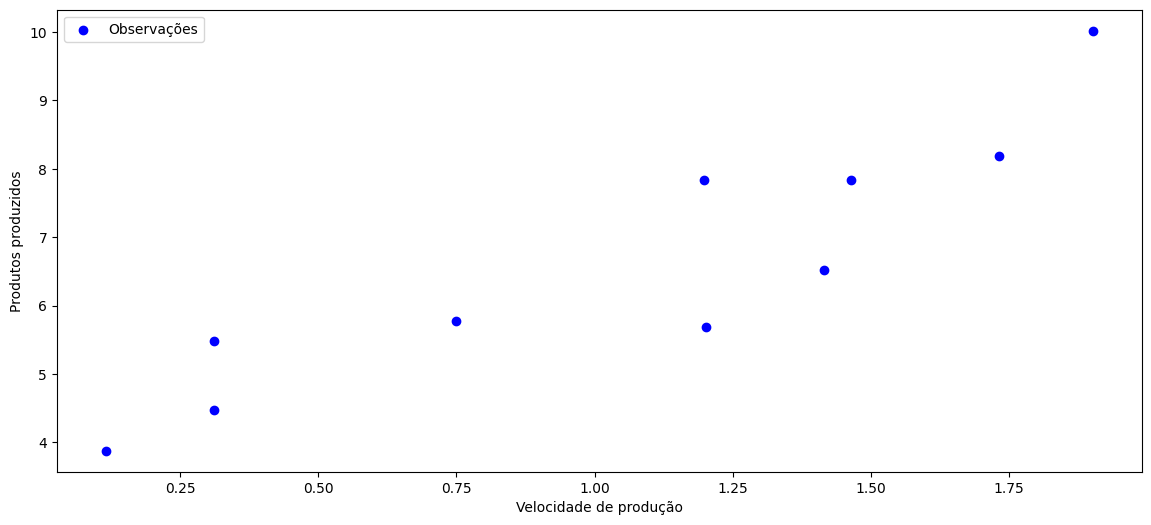

In [2]:
fig, axs = plt.subplots(1, 1, figsize=(14, 6))
axs.scatter(X,y, color='blue', label='Observações')
# Adiciona a legenda
plt.legend()
# Adiciona rótulos dos eixos
plt.xlabel("Velocidade de produção")
plt.ylabel("Produtos produzidos")
plt.show()

Passo 3: Testa-se um modelo simples

Um primeiro modelo mais intuitivo é encontrar a média dos valores e adotar esse como se fosse o modelo.

Médias dos valores de produção é 6.569503524584387


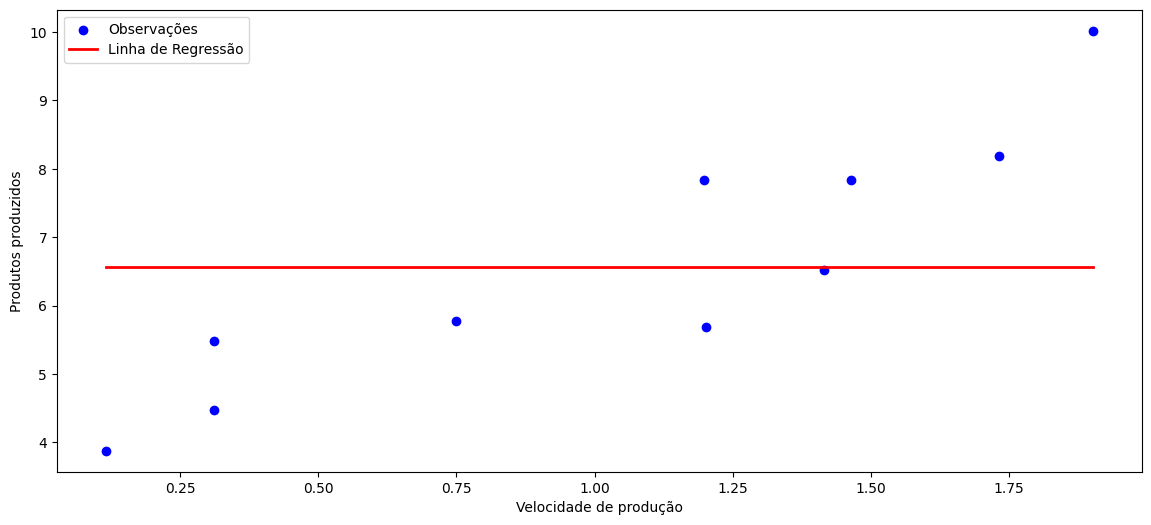

In [3]:
# Primeiro modelo: calcula-se a média dos valores de y
y_mean = np.mean(y)
print(f"Médias dos valores de produção é {y_mean}")

# Repetindo esse valor para cada valor de X, temos um vetor com a média
# y_pred é o valor predito para os valores X, utilizando um modelo que retoran a média dos valores
y_pred = np.array([y_mean for _ in range(len(X))])

# Plotando no gráfico
fig, axs = plt.subplots(1, 1, figsize=(14, 6))
# Plota os pontos
axs.scatter(X,y, color='blue', label='Observações')
# Plota o modelo
axs.plot(X, y_pred, color='red',linewidth=2, label='Linha de Regressão')
# Adiciona a legenda
plt.legend()
# Adiciona rótulos dos eixos
plt.xlabel("Velocidade de produção")
plt.ylabel("Produtos produzidos")
plt.show()

Passo 4: Encontrando a soma do quadrado dos resíduos

1. Para cada ponto (azul) é verificado então sua distância ao modelo (vermelho).
2. Eleva-se ao quadrado cada uma dessas distâncias (diferenças)
3. Soma-se esses quadrado das diferenças

In [6]:
# Distância ponto ao modelo
residuais = y_pred - y

# Residuais ao quadrado
residuais_sq = np.power(residuais, 2)

# Soma do quadrado dos resíduos
soma_residuos_sq = np.sum(residuais_sq)

print(f"Soma do quadrado dos resíduos (SSR): {soma_residuos_sq.item():.2f}")

Soma do quadrado dos resíduos (SSR): 319.06


Para ilustrar o andamento, plotam-se as linhas de diferença (laranja) entre o valor real (pontos em azul) e o valor que seria no modelo (linha em vermelho).


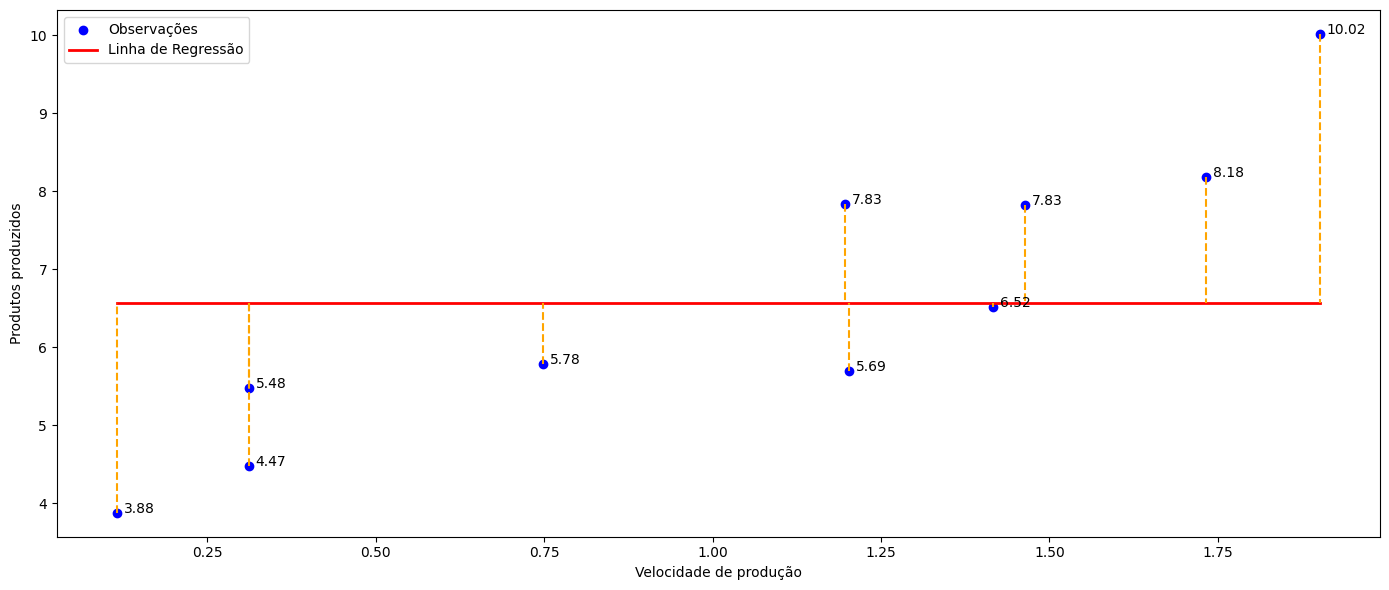

In [4]:
# Plotando no gráfico
fig, axs = plt.subplots(1, 1, figsize=(14, 6))
# Plota os pontos
axs.scatter(X,y, color='blue', label='Observações')
# Plota o modelo
axs.plot(X, y_pred, color='red',linewidth=2, label='Linha de Regressão')

# Plota as distâncias entre pontos e modelo
for i in range(len(X)):
  # Plota as linhas das distâncias em laranja
  axs.plot([X[i], X[i]], [y[i], np.array([y_pred[i]])], color='orange', linestyle='dashed')
  # Adiociona o rótulo do valor observado
  axs.text(x= X[i]+.01, y= y[i], s=str(np.round([*y[i]][0],2)))

# Adiciona a legenda
plt.legend()
# Adiciona rótulos dos eixos
plt.xlabel("Velocidade de produção")
plt.ylabel("Produtos produzidos")
plt.tight_layout()
plt.show()

Passo 5: Testa-se um novo modelo (gira a reta vermelha) e e verifica-se o SSR (soma do quadrado dos resíduos).

Um novo modelo poderia ser: \
$ y = 4 + 1.5 * X $

Então aplica-se o Passo 4 novamente.

In [5]:
# Novo modelo
y_pred = 4 + 1.5 * X

# Distância ponto ao modelo
residuais = y_pred - y

# Residuais ao quadrado
residuais_sq = np.power(residuais, 2)

# Soma do quadrado dos resíduos
soma_residuos_sq = sum(residuais_sq)

print(f"Soma do quadrado dos resíduos (SSR): {soma_residuos_sq.item():.2f}")

Soma do quadrado dos resíduos (SSR): 21.08


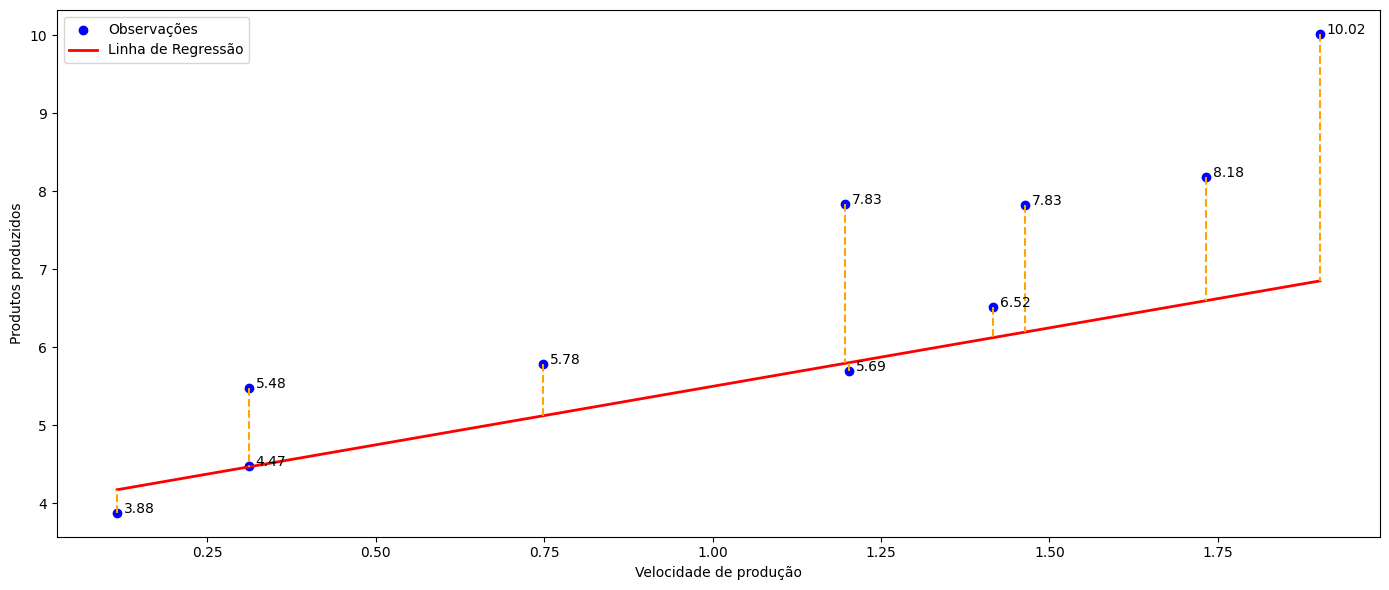

In [6]:
# Plotando no gráfico
fig, axs = plt.subplots(1, 1, figsize=(14, 6))
# Plota os pontos
axs.scatter(X,y, color='blue', label='Observações')
# Plota o modelo
axs.plot(X, y_pred, color='red',linewidth=2, label='Linha de Regressão')

# Plota as distâncias entre pontos e modelo
for i in range(len(X)):
    # Plota as linhas das distâncias
    axs.plot([X[i], X[i]], [y[i], y_pred[i]], color='orange', linestyle='dashed')
    # Adiociona o rótulo do valor observado
    axs.text(x= X[i]+.01, y= y[i], s=str(np.round([*y[i]][0],2)))

# Adiciona a legenda
plt.legend()
# Adiciona rótulos dos eixos
plt.xlabel("Velocidade de produção")
plt.ylabel("Produtos produzidos")
plt.tight_layout()
plt.show()

Na primeira iteração foi obtido SSR de 319.06.

Na segunda iteração foi obtido valor de SSR de 21.08, portanto o segundo modelo é melhor que o primeiro.

Esse processo de teste de modelos se repete até que se encontre o valor mínimo do SSR.

O processo de otimização que identifica o menor SSR chama-se **Método dos mínimos quadrados**

### Regressão com uso do sklearn

Aqui será abordado o emprego direto de modelos de regressão utilizando a biblioteca sklearn.

Esses modelos são de simples implementação, porém é necessario o entendimento de seu funcionamento, o ajuste de parâmetros, portanto a documentação deve ser sempre consultada.

Serão abordados os algoritmos: regressão linear, regressão ridge, árvores de decisão e redes neurais recorrentes.

### Criação do dataset para treino dos modelos

O conjunto de dados Diabetes disponível através do `load_diabetes()` do Scikit-learn é um conjunto de dados padrão, frequentemente utilizado para fins de aprendizado e demonstração em tarefas de machine learning. Ele contém informações sobre pacientes com diabetes, incluindo diversas características médicas como idade, sexo, índice de massa corporal (IMC), pressão arterial, níveis de glicose, etc.

Suas principais caractrísticas são:

- **Dados reais**: Os dados são provenientes de um estudo real sobre diabetes, o que o torna um conjunto de dados realista para testar algoritmos de aprendizado de máquina.
- **Variedade de features**: O dataset possui um número considerável de features, o que permite explorar diferentes técnicas de seleção e engenharia de features.
- **Target**: O objetivo (target) é uma medida quantitativa da progressão da doença, o que o torna um problema de regressão.


In [1]:
# Importação da biblioteca
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Carregar um conjunto de dados de exemplo
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
# Em X ficam os dados de características que serão os preditores do progresso da doença
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
# Em y, ficam os valroes de progresso da doença
y = diabetes.target

# Explicação do dataset
print(diabetes.DESCR)

ModuleNotFoundError: No module named 'tensorflow'